In [ ]:
import numpy as np
import torch, torchaudio
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import os

import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="torchaudio")

# Add this at the beginning of your notebook:
import torch._inductor.config as config
config.triton.cudagraphs = False

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

torch.manual_seed(1337)
if torch.cuda.is_available():
    torch.cuda.manual_seed(1337)

if torch.cuda.is_available():
    major, minor = torch.cuda.get_device_capability()
    print(f"Compute Capability: {major}.{minor}")
    if major >= 8:
        print("✅ TF32 is supported (Ampere or newer).")
    else:
        print("❌ TF32 is not supported.")

os.environ['CUDA_LAUNCH_BLOCKING'] = '1'
os.environ['TORCH_USE_CUDA_DSA'] = '1'  # For better debugging
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True
torch.backends.cudnn.benchmark = True
scaler = torch.amp.GradScaler('cuda', enabled=True)

In [ ]:
X = torch.rand((2, 1, 4))
dilation=2

X = F.pad(X, (dilation, 0))
print(X)

conv1d = nn.Conv1d(1, 1, 2, padding=0, dilation=dilation)
print(conv1d.weight)

w = conv1d.weight.detach().numpy()
b = conv1d.bias.detach().numpy()
x = X.numpy()
conv_x = conv1d(X)
print("w = ", w, "\nb = ", b)
print(f"Conv : {conv_x}\n")

x1 = x[0,0,:]
y = []
for i in range(len(x1) - dilation):
    print(f"{x1[i]}, {x1[i+dilation]}, * {w[0][0]} + {b[0]}, = \
        {np.sum([x1[i], x1[i+dilation]] * w[0][0]) + b[0]}")
    y.append(np.sum([x1[i], x1[i+dilation]] * w[0][0]) + b[0])
y = torch.Tensor(y)

print(y, conv_x[0][0])

In [ ]:
class SegmentedTokensOnDisk(torch.utils.data.Dataset):
    def __init__(self, manifest_path, root=None, cache_shards=True):
        import json, torch
        from pathlib import Path
        mp = Path(manifest_path)
        man = json.loads(mp.read_text())
        self.root = mp.parent if root is None else Path(root)
        self.files = [self.root / s for s in man["shards"]]
        self.sizes = man["shard_sizes"]
        self.cum = []
        c = 0
        for s in self.sizes:
            c += s
            self.cum.append(c)
        self.N = man["num_samples"]
        self.T = man["seq_len"]
        self.cache = {}
        self.stored_dtype = man.get("stored_dtype", "long")
        self.current_shard = -1

    def __len__(self): return self.N

    def _loc(self, idx):
        import bisect
        s_idx = bisect.bisect_right(self.cum, idx)
        base = 0 if s_idx == 0 else self.cum[s_idx-1]
        off = idx - base
        return s_idx, off
    
    def get_shard(self, s_idx):
        # print(f"Getting shard {s_idx} , current shard {self.current_shard}")
        if self.current_shard != s_idx:
            self.cache = {}
            self.current_shard = -1
        
        self.current_shard = s_idx
        
        if s_idx in self.cache:
            shard = self.cache[s_idx]
        else:
            print(f"Loading shard {s_idx} from {self.files[s_idx]}")
            shard = torch.load(self.files[s_idx], map_location="cpu")
            self.cache[s_idx] = shard
        return shard

    def __getitem__(self, idx):
        s_idx, off = self._loc(idx)
        shard = self.get_shard(s_idx)
        if self.stored_dtype == "uint8":
            x = shard["x_u8"][off].to(torch.long)  # upcast once
            y = shard["y_u8"][off].to(torch.long)
        else:
            x = shard["x"][off]
            y = shard["y"][off]
        if (x.gt(255).any() or y.gt(255).any()) or (x.lt(0).any() or y.lt(0).any()):
            # Log once if you want
            x.clamp_(0, 255); y.clamp_(0, 255)
        return x, y

In [ ]:
from IPython.display import Audio, display

dataset = SegmentedTokensOnDisk("segmented_tokens/manifest.json", cache_shards=False)

# Print dataset info.
print(f"Number of samples in dataset: {len(dataset)}")

In [ ]:
class MuLawEncoding:
    def __init__(self, quantization_channels: int = 256):
        self.Q = quantization_channels
        self.enc = torchaudio.transforms.MuLawEncoding(self.Q)
        self.dec = torchaudio.transforms.MuLawDecoding(self.Q)

    @torch.no_grad()
    def mu_law_encode(self, x: torch.Tensor) -> torch.LongTensor:
        # x: [..., T] float in [-1, 1]
        return self.enc(x)

    @torch.no_grad()
    def mu_law_decode(self, q: torch.Tensor) -> torch.Tensor:
        # q: [..., T] long/int in [0, Q-1]
        return self.dec(q)
    
# Save codec once and use everywhere.
codec = MuLawEncoding(256)


In [ ]:
config = {
    "batch_size": 4,
    "num_workers": 2,  # CHANGED: Use 0 for debugging, multiprocessing can cause issues
    "pin_memory": True,
    "mu": 256,
    "sr": 16000,
    "trim_silence_thresh": 1e-3,
    "window_size": 32001,  # ~2 seconds at 16kHz

    # Wavenet architecture related.
    "residual_channels": 64,
    "skip_channels": 256,
    "output_dim": 256,
    "n_layers": 10,
    "n_blocks": 5,
    "kernel_size": 2,
    'hop_size': 16000,
}


In [ ]:
def display_waveform(audio, title=""):
    plt.figure(figsize=(14,4))
    plt.plot(audio.t().numpy())
    plt.title(f"Audio: {title}")
    plt.tight_layout()
    plt.show()

def play_encoded_sample(tokens: torch.Tensor, sr: int = config['sr']) -> None:
    # tokens: [T] or [1,T] long
    if tokens.dim() == 1:
        tokens = tokens.unsqueeze(0)
    wav = codec.mu_law_decode(tokens).squeeze(0).cpu().numpy()  # in [-1, 1]
    display(Audio(wav, rate=config['sr']))

def play_batch(batch):
    audio, _ = batch  
    audio = audio[0] # Get first item from batch
    play_encoded_sample(audio)

def plot_encoded_sample(tokens: torch.Tensor, sr: int, title=""):
    wav = codec.mu_law_decode(tokens if tokens.dim()==2 else tokens.unsqueeze(0)).squeeze(0).cpu()
    display_waveform(wav.unsqueeze(0), title)  # your plotting util expects [1,T]

# # Get first audio sample and plot waveform.
# audio_x, audio_y = dataset[0]

# display_waveform(audio_x)
# play_encoded_sample(audio_x)

In [ ]:
class AudioProcessor:
    def __init__(self):
        self.mu_law_encoding = codec
        self.resamplers = {}  # Cache resamplers for efficiency

    def normalize(self, x):
        # Ensure audio is float32 and normalize to [-1, 1]
        if x.dtype != torch.float32:
            x = x.float()
        
        # peak normalization
        max_val = torch.max(torch.abs(x))
        if max_val > 0:  # Avoid division by zero
            x = x / max_val
        
        # rms normalization (optional)
        target_rms = 0.1
        def rms(x):
            return torch.sqrt(torch.mean(x**2) + 1e-8)
        current_rms = rms(x)
        if current_rms > 0:  # Avoid division by zero
            x = x * (target_rms / current_rms)

        return x

    def resample_audio(self, audio, orig_sr, target_sr):
        if orig_sr == target_sr:
            return audio
            
        # Use cached resampler for efficiency
        resampler_key = f"{orig_sr}_{target_sr}"
        if resampler_key not in self.resamplers:
            self.resamplers[resampler_key] = torchaudio.transforms.Resample(
                orig_freq=orig_sr,
                new_freq=target_sr
            )
        
        return self.resamplers[resampler_key](audio)

    # Trim leading/trailing silence
    def trim_silence(self, sig, thresh=config['trim_silence_thresh']):
        # sig: [1,T] tensor
        # returns: [1,T'] tensor with silence trimmed
        # Calculate energy
        energy = sig.abs().squeeze()
        # Find indices where energy is above threshold
        idx = torch.where(energy > thresh)[0]
        if len(idx) == 0:
            return sig  # Return original if no samples above threshold
        # Return trimmed signal
        return sig[:, idx[0].item():idx[-1].item() + 1]

    def segment_audio(self, audio, drop_last=True, hop_size=None):
        """
        Split [1, T] into windows of size config['window_size'].
        - hop_size=None → non-overlapping
        - hop_size < window_size → overlapping
        - drop_last=True → drop incomplete tail (recommended to avoid padding loss)
        """
        window_size = config['window_size']
        hop = hop_size or window_size
        T = audio.shape[1]

        segments = []
        # all full windows
        for start in range(0, T - window_size + 1, hop):
            segments.append(audio[:, start:start + window_size])

        # optional last (padded) window
        if not drop_last and (T < window_size or (T - window_size) % hop != 0):
            last_start = max(0, T - window_size)
            tail = audio[:, last_start:]
            if tail.shape[1] < window_size:
                tail = F.pad(tail, (0, window_size - tail.shape[1]))
            segments.append(tail)

        return segments
        
    def collate_fn(self, batch):
        """
        Returns:
            x: LongTensor [B_total, W-1]
            y: LongTensor [B_total, W-1]
        where B_total = sum of (#segments per item in batch).
        """
        x_list, y_list = [], []

        for (audio, sr, text, normalized_text) in batch:
            # resample → (optional) trim → normalize
            audio = self.resample_audio(audio, sr, config['sr'])
            audio = self.trim_silence(audio)              # you can disable if you want
            audio = self.normalize(audio)                 # peak-normalize only

            if audio.size(0) > 1:                         # safety: downmix stereo
                audio = audio.mean(dim=0, keepdim=True)

            # Generate multiple segments
            segments = self.segment_audio(
                audio,
                drop_last=True,                           # avoid padded tails in loss
                hop_size=config.get('hop_size', 16000)     # e.g., 16000 for 50% overlap @32000
            )

            # convert each segment to tokens and teacher-forced pairs
            for seg in segments:
                q = self.mu_law_encoding.mu_law_encode(seg.squeeze(0))  # [W]
                x_list.append(q[:-1])
                y_list.append(q[1:])

        if len(x_list) == 0:
            return (torch.empty(0, 0, dtype=torch.long),
                    torch.empty(0, 0, dtype=torch.long))

        max_len = max(t.size(0) for t in x_list)
        x = torch.stack([F.pad(t, (0, max_len - t.size(0)), value=0) for t in x_list], dim=0)
        y = torch.stack([F.pad(t, (0, max_len - t.size(0)), value=0) for t in y_list], dim=0)
        return x.long(), y.long()


In [ ]:
from torch.utils.data import Subset

# Split dataset into train and test sets (90-10 split)
train_size = int(0.9 * len(dataset))
test_size = len(dataset) - train_size
# Indices for train and test
train_indices = list(range(0, train_size))
test_indices = list(range(train_size, len(dataset)))

# Subsets
train_dataset = Subset(dataset, train_indices)
test_dataset = Subset(dataset, test_indices)

# train_dataset, test_dataset = torch.utils.data.random_split(
#     dataset, 
#     [train_size, test_size]
# )
fake_train_dataset, fake_test_dataset = Subset(dataset, [0]), Subset(dataset, [0])

print(f"Training set size: {len(train_dataset)}")
print(f"Test set size: {len(test_dataset)}")
print(f"Fake training set size: {len(fake_train_dataset)}")
print(f"Fake test set size: {len(fake_test_dataset)}")

In [ ]:
# Audio processor.
audio_processor = AudioProcessor()

# Create dataloaders
train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=config['batch_size'],
    num_workers= 0,
    persistent_workers=False,         
)
test_loader = torch.utils.data.DataLoader(
    test_dataset, 
    batch_size=config['batch_size'],
    num_workers= 0,
    persistent_workers=False,         
)
print(f"Number of training batches: {len(train_loader)}")
print(f"Number of test batches: {len(test_loader)}")

# # Create dataloaders
# Old dataloaders which loaded original dataset and not the saved one.
# train_loader = torch.utils.data.DataLoader(
#     train_dataset,
#     batch_size=config['batch_size'],
#     shuffle=True,
#     num_workers= max(4, os.cpu_count()//2),
#     pin_memory=True,
#     persistent_workers=True,         # keeps workers alive between iters
#     prefetch_factor=4,
#     collate_fn=lambda batch: audio_processor.collate_fn(batch),
# )
# test_loader = torch.utils.data.DataLoader(
#     test_dataset, 
#     batch_size=config['batch_size'],
#     shuffle=False,
#     num_workers= max(4, os.cpu_count()//2),
#     pin_memory=True,
#     persistent_workers=True,         # keeps workers alive between iters
#     prefetch_factor=4,
#     collate_fn=lambda batch: audio_processor.collate_fn(batch),
# )
# print(f"Number of training batches: {len(train_loader)}")
# print(f"Number of test batches: {len(test_loader)}")

def fake_collate_fn(batch):
    x, y = audio_processor.collate_fn(batch)
    return x[0].unsqueeze(0), y[0].unsqueeze(0)

fake_train_loader = torch.utils.data.DataLoader(
    fake_train_dataset,
    batch_size=1,
    shuffle=True,
    num_workers=0,
    pin_memory=True,
    # collate_fn=fake_collate_fn,
)
fake_test_loader = torch.utils.data.DataLoader(
    fake_test_dataset, 
    batch_size=1,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
    # collate_fn=fake_collate_fn,
)


In [ ]:
for batch in train_loader:
    print(batch[0].shape)
    play_encoded_sample(batch[0])
    break

In [ ]:
def sanity(x, y):
    print("x dtype:", x.dtype, "min:", int(x.min()), "max:", int(x.max()))
    print("y dtype:", y.dtype, "min:", int(y.min()), "max:", int(y.max()))
    assert x.dtype == torch.long and y.dtype == torch.long
    assert (x >= 0).all() and (x <= 255).all()
    assert (y >= 0).all() and (y <= 255).all()

for i, (x, y) in enumerate(train_loader):
    sanity(x, y)
    if i > 100:
        break

In [ ]:
class CausalDilatedConvolution(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=2, dilation=1):
        super().__init__()
        self.kernel_size = kernel_size
        self.dilation = dilation
        self.conv1d = nn.Conv1d(
            in_channels, 
            out_channels,
            kernel_size=kernel_size, 
            dilation=dilation, 
            padding=0, 
            bias=True)
    
    def forward(self, x):
        if self.kernel_size > 1:
            x = F.pad(x, ((self.kernel_size - 1) * self.dilation, 0), mode='constant', value=0)
        return self.conv1d(x)


In [ ]:
class ResidualBlock(nn.Module):
    def __init__(self, C_res, C_skip, dilation=1):
        super().__init__()
        self.dilated_conv = CausalDilatedConvolution(C_res, 2* C_res, kernel_size=2, dilation=dilation)
        # self.filter_conv = CausalDilatedConvolution(C_res, C_res, kernel_size=2, dilation=dilation)
        # self.gate_conv = CausalDilatedConvolution(C_res, C_res, kernel_size=2, dilation=dilation)
        self.skip_conv1x1 = nn.Conv1d(C_res, C_skip, 1)
        self.res_conv1x1 = nn.Conv1d(C_res, C_res, 1)
        
    def forward(self, x):
        output = self.dilated_conv(x)
        # Split into two halves along the channel dimension (dim=1)
        # Each half has shape: [B, C_res, T]
        filter_out, gate_out = torch.chunk(output, 2, dim=1)

        # Apply the gated activation unit
        gated = torch.tanh(filter_out) * torch.sigmoid(gate_out)

        # 1x1 convolutions for residual and skip connections
        residual = self.res_conv1x1(gated)
        skip = self.skip_conv1x1(gated)

        # Return the residual connection (for the next block) and the skip connection (for the final output)
        return residual + x, skip
   

In [ ]:
class Wavenet(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config
        self.C_res  = config['residual_channels']
        self.C_output = config['output_dim']
        self.C_skip = config['skip_channels']
        self.kernel_size = config['kernel_size']
        self._rf = self._compute_receptive_field()
        
        # Converts [B, T] to [B, T, C_res]
        self.embedding = nn.Embedding(self.C_output, self.C_res, dtype=torch.float32)
        
        # For stability.
        self.conv1d = nn.Conv1d(self.C_res, self.C_res, kernel_size=1)
        
        # Each block has N-layers with dilations = 1,2,4,8,...512.
        self.residual_blocks = nn.ModuleList([
            self._create_residual_block() for i in range(config['n_blocks'])
        ])
        self.output_head = nn.Sequential(
            nn.ReLU(),
            nn.Conv1d(self.C_skip, self.C_skip, kernel_size=1),
            nn.ReLU(),
            nn.Conv1d(self.C_skip, self.C_output, kernel_size=1))
    
    def _create_residual_block(self):
        # Each residual block has n-layers with dilations = 1,2,4,8,...512
        return nn.ModuleList([
            ResidualBlock(self.C_res, self.C_skip, dilation=2**i)
            for i in range(self.config['n_layers'])
        ])

    def forward(self, x):
        # [B, T] -> [B, T, C]
        x_embd = self.embedding(x)
        # [B, T, C] -> [B, C, T]
        x_embd = x_embd.permute(0, 2, 1)
        skip_output = None
        
        # [B, C_hidden, T] as all convolutions expect this structure.
        x_embd = self.conv1d(x_embd)
        
        for residual_block in self.residual_blocks:
            for layer in residual_block:
                x_embd, x_skip = layer(x_embd)
                skip_output = x_skip if skip_output is None else skip_output + x_skip

        output = self.output_head(skip_output)
        
        # [B, T, C_output] again.
        return output.permute(0, 2, 1)
    
    def _compute_receptive_field(self):
        # RF = 1 + B * (2^L - 1)  (for k=2)
        if self.kernel_size != 2:
            # general: RF = 1 + B * sum_{i=0..L-1} (k-1)*2^i
            return 1 + self.config['n_blocks'] * ((self.kernel_size - 1) * (2**self.config['n_layers'] - 1))
        return 1 + self.config['n_blocks'] * (2**self.config['n_layers'] - 1)
    
    def get_receptive_field(self):
        return self._rf


In [ ]:
# Figure out dataloaders, etc. based on training requirements.
# Fake dataset setup to test if training is working and is able to overfit on 1 sample.
USE_FAKE = False
if USE_FAKE:
    config['batch_size'] = 1
    config['num_workers'] = 0

checkpoint_dir = './wavenet_checkpoints_fake' if USE_FAKE else './wavenet_checkpoints'
os.makedirs(checkpoint_dir, exist_ok=True)

train_loader = fake_train_loader if USE_FAKE else train_loader
test_loader = fake_test_loader if USE_FAKE else test_loader


In [ ]:
class Model:
    def __init__(self, config, base_model, checkpoint_dir):
        self.config = config
        self.base_model = base_model
        self.model_train = None
        self.model_eval = None
        self.checkpoint_dir = checkpoint_dir

    def _find_checkpoints(self):
        """Find the most recent checkpoint"""
        latest_path = self._get_latest_checkpoint_path()
        best_path = self._get_best_checkpoint_path()
        latest_path = latest_path if os.path.exists(latest_path) else None
        best_path = best_path if os.path.exists(best_path) else None
        return latest_path, best_path
    
    def _get_best_checkpoint_path(self):
        return os.path.join(self.checkpoint_dir, 'best_model.pth')
    
    def _get_latest_checkpoint_path(self):
        return os.path.join(self.checkpoint_dir, 'latest_checkpoint.pth')
    
    def _compile_for_training(self):
        self.base_model.train()
        return torch.compile(self.base_model, mode="reduce-overhead")  # no flip to eval on this
    
    def _compile_for_eval(self):
        self.base_model.eval()
        return torch.compile(self.base_model, mode="reduce-overhead")
    
    def get_receptive_field(self):
        return self.base_model.get_receptive_field()


class TrainableModel(Model):
    def __init__(self, config, checkpoint_dir, base_model, optimizer, scheduler, load_from_checkpoint=False):
        super().__init__(config, base_model, checkpoint_dir)
        
        self.base_model = base_model
        self.optimizer = optimizer
        self.scheduler = scheduler
        self.training_stats = {
            'train_losses': [],
            'val_losses': [],
            'train_accuracies': [],
            'val_accuracies': [],
            'best_val_loss': float('inf'),
        }
        # 0 indexed epoch till which the model has been trained. -1 for untrained model.
        self.trained_till_epoch_index = -1
        if load_from_checkpoint:
            self._load_from_checkpoint()
        
        # Model to be used only for training.
        self.compiled_model = self._compile_for_training()

    
    def save(self, epoch, training_stats, learning_rate, is_best=False):
        """Save checkpoint with all training state and the base model."""
        checkpoint = {
            'config': self.config,
            'model_state_dict': self.base_model.state_dict(),
            'optimizer_state_dict': self.optimizer.state_dict(),
            'scheduler_state_dict': self.scheduler.state_dict(),
            
            'train_losses': training_stats['train_losses'],
            'val_losses': training_stats['val_losses'],
            'train_accuracies': training_stats['train_accuracies'],
            'val_accuracies': training_stats['val_accuracies'],
            'best_val_loss': training_stats['best_val_loss'],
            
            'trained_till_epoch_index': epoch,
            'learning_rate': learning_rate
        }
        
        # Save latest checkpoint for training.
        torch.save(checkpoint, self._get_latest_checkpoint_path())
        
        # Save best model, for eval.
        if is_best:
            torch.save(checkpoint, self._get_best_checkpoint_path())
            print(f"💾 New best model saved! Val Loss: {training_stats['best_val_loss']:.4f}")

    def _load_from_checkpoint(self):
        latest_checkpoint_path, _ = self._find_checkpoints()
        
        if not latest_checkpoint_path:
            print("🆕 No existing checkpoints found. Loading base model.")
            return
        
        print(f"🔄 Loading model checkpoint from: {latest_checkpoint_path}")
        checkpoint = torch.load(latest_checkpoint_path, map_location=device)
        
        self.base_model.load_state_dict(checkpoint['model_state_dict'])
        self.optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        if 'scheduler_state_dict' in checkpoint:
            self.scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
        
        # Load training metrics
        train_losses = checkpoint.get('train_losses', [])
        val_losses = checkpoint.get('val_losses', [])
        train_accuracies = checkpoint.get('train_accuracies', [])
        val_accuracies = checkpoint.get('val_accuracies', [])
        best_val_loss = checkpoint.get('best_val_loss', float('inf'))
        self.trained_till_epoch_index = checkpoint.get('trained_till_epoch_index', -1)
        self.training_stats = {
            'train_losses': train_losses,
            'val_losses': val_losses,
            'train_accuracies': train_accuracies,
            'val_accuracies': val_accuracies,
            'best_val_loss': best_val_loss,
        }
        print(f"✅ Checkpoint loaded successfully. Trained for {self.trained_till_epoch_index + 1} epochs!")
        
    
class EvalModel(Model):
    def __init__(self, config, checkpoint_dir, base_model):
        super().__init__(config, base_model, checkpoint_dir)
        self.base_model = base_model
        self._load_from_checkpoint()
        
        # Model to be used only for evaluation.
        self.compiled_model = self.base_model #self._compile_for_eval()
    
    def _load_from_checkpoint(self):
        _, best_checkpoint_path = self._find_checkpoints()
        
        if not best_checkpoint_path:
            print("🆕 No existing checkpoints found for evaluation")
            return
        
        print(f"🔄 Loading eval model checkpoint from: {best_checkpoint_path}")
        checkpoint = torch.load(best_checkpoint_path, map_location=device)
        self.base_model.load_state_dict(checkpoint['model_state_dict'])
        
        epoch = checkpoint.get('trained_till_epoch_index', 0)
        print(f"✅ Eval model checkpoint loaded successfully. Trained till epoch {epoch + 1}!")


In [ ]:
class Trainer:
    def __init__(self, 
                 base_model,
                 trainable_model,
                 config, 
                 learning_rate, 
                 optimizer, 
                 scheduler, 
                 checkpoint_dir, 
                 train_loader, 
                 val_loader, 
                 device):
        self.device = device
        self.base_model = base_model
        self.trainable_model = trainable_model
        self.compiled_model = self.trainable_model.compiled_model
        
        self.learning_rate = learning_rate
        self.optimizer = optimizer
        self.scheduler = scheduler
        self.checkpoint_dir = checkpoint_dir
        self.train_loader = train_loader
        self.val_loader = val_loader
        
        self.training_stats = self.trainable_model.training_stats
        self.start_epoch = self.trainable_model.trained_till_epoch_index + 1
        
    def prepare_batch(self, batch, device):
        """Prepare batch for autoregressive training"""
        audio_x, audio_y = batch
        return audio_x.to(device), audio_y.to(device)

    def calculate_accuracy(self, output, target):
        """Calculate prediction accuracy"""
        pred = torch.argmax(output, dim=-1)
        correct = (pred == target).sum().item()
        total = target.numel()
        return correct / total

    def train_epoch(self):
        """Train for one epoch"""
        self.base_model.train()
        self.compiled_model.train()
        
        total_loss = 0.0
        total_accuracy = 0.0
        num_batches = 0
        
        pbar = tqdm(self.train_loader, desc="Training", leave=False)
        
        for batch in pbar:
            try:
                audio_x, audio_y = self.prepare_batch(batch, self.device)
                self.optimizer.zero_grad(set_to_none=True)
                
                with torch.amp.autocast("cuda", dtype=torch.float16):
                    output = self.compiled_model(audio_x)                     # [B,T,256] in fp16
                    B, T, C = output.shape
                    output_flat = output.reshape(-1, C)
                    target_flat = audio_y.reshape(-1)
                    loss = F.cross_entropy(output_flat, target_flat)  # CE supports fp16

                accuracy = self.calculate_accuracy(output_flat, target_flat)
                
                scaler.scale(loss).backward()
                scaler.unscale_(self.optimizer)
                torch.nn.utils.clip_grad_norm_(self.base_model.parameters(), 1.0)
                scaler.step(self.optimizer)
                scaler.update()

                total_loss += loss.item()
                total_accuracy += accuracy
                num_batches += 1
                
                pbar.set_postfix({
                    'Loss': f'{loss.item():.4f}',
                    'Acc': f'{accuracy:.3f}'
                })
                
            except Exception as e:
                print(f"Error in training batch: {e}")
        
        return total_loss / max(num_batches, 1), total_accuracy / max(num_batches, 1)

    def validate_epoch(self):
        """Validate for one epoch"""
        self.base_model.eval()
        
        total_loss = 0.0
        total_accuracy = 0.0
        num_batches = 0
        
        with torch.no_grad():
            pbar = tqdm(test_loader, desc="Validation", leave=False)
            
            for batch in pbar:
                try:
                    audio_x, audio_y = self.prepare_batch(batch, device)
                    with torch.no_grad(), torch.amp.autocast('cuda', dtype=torch.float16):
                        output = self.base_model(audio_x)
                        B,T,C = output.shape
                        output_flat = output.reshape(-1, C)
                        target_flat = audio_y.reshape(-1)
                        loss = F.cross_entropy(output_flat, target_flat)
                    
                    accuracy = self.calculate_accuracy(output_flat, target_flat)
                    
                    total_loss += loss.item()
                    total_accuracy += accuracy
                    num_batches += 1
                    
                    pbar.set_postfix({
                        'Val Loss': f'{loss.item():.4f}',
                        'Val Acc': f'{accuracy:.3f}'
                    })
                    
                except Exception as e:
                    print(f"Error in validation batch: {e}")
                    continue
        
        return total_loss / max(num_batches, 1), total_accuracy / max(num_batches, 1)

    def plot_training_progress(self, epoch):
        """Plot training progress with history"""
        train_losses = self.training_stats['train_losses']
        val_losses = self.training_stats['val_losses']
        train_accuracies = self.training_stats['train_accuracies']
        val_accuracies = self.training_stats['val_accuracies']
        
        if len(train_losses) == 0:
            return
        
        plt.figure(figsize=(15, 5)) 
        
        # Loss plot
        plt.subplot(1, 3, 1)
        epochs_range = range(1, len(train_losses) + 1)
        plt.plot(epochs_range, train_losses, 'b-', label='Training Loss', linewidth=2)
        plt.plot(epochs_range, val_losses, 'r-', label='Validation Loss', linewidth=2)
        plt.title(f'Training Progress (Epoch {epoch+1})')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        # Accuracy plot
        plt.subplot(1, 3, 2)
        plt.plot(epochs_range, train_accuracies, 'b-', label='Training Accuracy', linewidth=2)
        plt.plot(epochs_range, val_accuracies, 'r-', label='Validation Accuracy', linewidth=2)
        plt.title(f'Accuracy Progress (Epoch {epoch+1})')
        plt.xlabel('Epoch')
        plt.ylabel('Accuracy')
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        # Loss difference (overfitting indicator)
        plt.subplot(1, 3, 3)
        loss_diff = [v - t for t, v in zip(train_losses, val_losses)]
        plt.plot(epochs_range, loss_diff, 'g-', linewidth=2)
        plt.title('Overfitting Indicator (Val - Train Loss)')
        plt.xlabel('Epoch')
        plt.ylabel('Loss Difference')
        plt.axhline(y=0, color='k', linestyle='--', alpha=0.5)
        plt.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.savefig(os.path.join(checkpoint_dir, f'progress_epoch_{epoch+1}.png'), dpi=150)
        plt.show()

    def train(self, num_epochs):
        # Main training loop.
        if self.start_epoch >= num_epochs:
            print(f"Model is already trained to {num_epochs} epochs.")
            
        print(f"\n{'='*60}")
        print(f"🚀 Training...")
        print(f"📊 Epochs: {self.start_epoch} → {num_epochs}")
        print(f"{'='*60}")

        for epoch in range(self.start_epoch, num_epochs):
            print(f"\nEpoch {epoch+1}/{num_epochs}")
            
            # Training
            train_loss, train_acc = self.train_epoch()
            
            # Validation
            val_loss, val_acc = self.validate_epoch()
            
            # Update scheduler
            self.scheduler.step(val_loss)
            
            # Save metrics
            self.training_stats['train_losses'].append(train_loss)
            self.training_stats['val_losses'].append(val_loss)
            self.training_stats['train_accuracies'].append(train_acc)
            self.training_stats['val_accuracies'].append(val_acc)
            
            # Check for best model
            is_best = val_loss < self.training_stats['best_val_loss']
            if is_best:
                self.training_stats['best_val_loss'] = val_loss
            
            # Save checkpoint every epoch.
            self.trainable_model.save(epoch, self.training_stats, self.learning_rate, is_best)
            
            # Print epoch summary
            improvement = "🔥" if is_best else ""
            print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.3f}")
            print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.3f} {improvement}")
            print(f"LR: {self.optimizer.param_groups[0]['lr']:.6f}")
            
            # Plot every 5 epochs or if it's the first resumed epoch
            if (epoch + 1) % 5 == 0 or epoch == self.start_epoch:
                self.plot_training_progress(epoch)

        print(f"\n🎉 Training completed!")
        print(f"Best validation loss: {self.training_stats['best_val_loss']:.4f}")
        print(f"Total epochs trained: {len(self.training_stats['train_losses'])}")
        print(f"Checkpoints saved in: {self.checkpoint_dir}")

        # Final comprehensive plot.
        self.plot_training_progress(len(self.training_stats['train_losses']) - 1)

        # Save final results
        final_results = {
            'total_epochs': len(self.training_stats['train_losses']),
            'best_val_loss': self.training_stats['best_val_loss'],
            'final_train_loss': self.training_stats['train_losses'][-1] if self.training_stats['train_losses'] else None,
            'final_val_loss': self.training_stats['val_losses'][-1] if self.training_stats['val_losses'] else None,
            'final_train_acc': self.training_stats['train_accuracies'][-1] if self.training_stats['train_accuracies'] else None,
            'final_val_acc': self.training_stats['val_accuracies'][-1] if self.training_stats['val_accuracies'] else None
        }

        import json
        with open(os.path.join(checkpoint_dir, 'training_summary.json'), 'w') as f:
            json.dump(final_results, f, indent=2)

        print(f"📋 Training summary saved to: {os.path.join(checkpoint_dir, 'training_summary.json')}")
        print(f"Training completed!")



In [ ]:
# Number of epochs to train for. 
# If the saved checkpoint is < num_epochs then training will be done.
# Otherwise model will be loaded and put in eval mode and compiled.
num_epochs = 50 if not USE_FAKE else 180  # 180 is enough to overfit completely.

# Initialize base model and optimizer.
base_model = Wavenet(config).to(device)
learning_rate = 1e-3
optimizer = torch.optim.AdamW(base_model.parameters(), lr=learning_rate) #, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=1, threshold=1e-3)

# Load the latest trainable model.
trainable_model = TrainableModel(config, checkpoint_dir, base_model, optimizer, scheduler, 
                                 load_from_checkpoint=True)
print(f"Model parameters: {sum(p.numel() for p in trainable_model.base_model.parameters()):,}")

if trainable_model.trained_till_epoch_index + 1 < num_epochs:
    print(f"🚀 {'Resuming' if trainable_model.trained_till_epoch_index > -1 else 'Starting'} WaveNet Training")
    # Create the trainer.
    trainer = Trainer(base_model, trainable_model, config, learning_rate, optimizer, scheduler, checkpoint_dir, train_loader, test_loader, device)
    trainer.train(num_epochs)
else:
    print(f"Model is already trained to {num_epochs} epochs.")

In [21]:
# Reload model for evals and generation.
base_model = Wavenet(config).to(device)
model = EvalModel(config, checkpoint_dir, base_model)

🔄 Loading eval model checkpoint from: ./wavenet_checkpoints/best_model.pth
✅ Eval model checkpoint loaded successfully. Trained till epoch 34!


In [22]:
import torch
import torch.nn.functional as F
from math import prod

@torch.no_grad()
def generate_continuation(
    model,
    seed_tokens: torch.LongTensor,   # [B, T_seed], class IDs in [0..255]
    n_steps: int,                    # how many new samples to generate
    temperature: float = 1.0,
    top_k: int | None = None,
    device: str | torch.device = "cuda",
    rf_override: int | None = None,  # optionally pass model RF
):
    model.eval()
    seq = seed_tokens.to(device)  # [B, T_seed]
    B = seq.size(0)
    assert B == 1, "start with batch size 1 for autoregressive generation"

    # try to infer RF from model config if not provided
    if rf_override is not None:
        rf = rf_override
    else:
        rf = model.get_receptive_field()

    for _ in tqdm(range(n_steps), desc='Generating'):
        # crop to receptive field context to save compute
        ctx = seq[:, -rf:] if seq.size(1) > rf else seq

        with torch.inference_mode(): #Generate in fp32 for stability, torch.amp.autocast("cuda", dtype=torch.float16):
            logits = model(ctx).float()          # [1, T_ctx, 256]
            logits = logits[:, -1, :]    # [1, 256] last step

        # temperature / top-k sampling (avoid argmax for better naturalness)
        logits = logits / max(temperature, 1e-6)
        if top_k is not None and top_k > 0:
            topk_vals, topk_idx = torch.topk(logits, k=top_k, dim=-1)
            probs = torch.zeros_like(logits).scatter(-1, topk_idx, F.softmax(topk_vals, dim=-1))
        else:
            probs = F.softmax(logits, dim=-1)

        next_tok = torch.multinomial(probs, num_samples=1)  # [1,1] Long
        seq = torch.cat([seq, next_tok], dim=1)             # append token

    return seq  # [1, T_seed + n_steps] (tokens)


@torch.no_grad()
def generate_greedy(model, seed, n_steps, device="cuda", rf=None):
    model.eval()
    seq = seed.to(device)
    rf = rf or model.get_receptive_field()
    for _ in tqdm(range(n_steps), desc='Generating'):
        ctx = seq[:, -rf:] if seq.size(1) > rf else seq
        logits = model(ctx)[:, -1, :].float()      # force fp32 for softmax/argmax stability
        nxt = logits.argmax(dim=-1, keepdim=True)  # greedy
        seq = torch.cat([seq, nxt], 1)
    return seq

In [23]:
import torch
import torch.nn.functional as F
from tqdm import tqdm

@torch.no_grad()
def generate_continuation_fixed(
    model,
    seed_tokens: torch.LongTensor,   # [B, T_seed]
    n_steps: int,
    temperature: float = 1.0,
    top_k: int | None = None,
    device: str | torch.device = "cuda",
    use_fp32: bool = True,  # Use FP32 for generation stability
):
    """Fixed generation function with proper FP32 handling"""
    model.eval()
    seq = seed_tokens.to(device)
    B = seq.size(0)
    assert B == 1, "Use batch size 1 for generation"
    
    rf = model.get_receptive_field()
    print(f"Using receptive field: {rf}")
    
    for step in tqdm(range(n_steps), desc='Generating'):
        # Crop to receptive field
        ctx = seq[:, -rf:] if seq.size(1) > rf else seq
        
        if use_fp32:
            # Use FP32 for stability
            with torch.inference_mode():
                logits = model(ctx).float()  # Force FP32
        else:
            # Use mixed precision
            with torch.inference_mode(), torch.amp.autocast("cuda", dtype=torch.float16):
                logits = model(ctx)
                logits = logits.float()  # Convert to FP32 for sampling
        
        logits = logits[:, -1, :]  # [1, 256] - last timestep
        
        # Apply temperature
        if temperature != 1.0:
            logits = logits / max(temperature, 1e-6)
        
        # Apply top-k filtering if specified
        if top_k is not None and top_k > 0:
            topk_vals, topk_idx = torch.topk(logits, k=min(top_k, logits.size(-1)), dim=-1)
            # Zero out non-top-k logits
            logits_filtered = torch.full_like(logits, float('-inf'))
            logits_filtered.scatter_(-1, topk_idx, topk_vals)
            logits = logits_filtered
        
        # Sample next token
        probs = F.softmax(logits, dim=-1)
        next_tok = torch.multinomial(probs, num_samples=1)  # [1, 1]
        
        # Append to sequence
        seq = torch.cat([seq, next_tok], dim=1)
        
        # Debug: Print some info every 1000 steps
        if step % 1000 == 0:
            prob_max = probs.max().item()
            entropy = -(probs * torch.log(probs + 1e-8)).sum().item()
            print(f"Step {step}: max_prob={prob_max:.3f}, entropy={entropy:.3f}, token={next_tok.item()}")
    
    return seq

@torch.no_grad()
def generate_with_teacher_forcing_test(model, seed_tokens, target_tokens, device="cuda"):
    """Test generation by comparing with teacher forcing"""
    model.eval()
    
    # Teacher forcing (what the model should predict)
    with torch.inference_mode():
        teacher_logits = model(target_tokens.to(device))  # [1, T, 256]
    
    # Autoregressive generation
    generated = seed_tokens.clone()
    rf = model.get_receptive_field()
    
    for i in tqdm(range(target_tokens.size(1) - seed_tokens.size(1))):
        ctx = generated[:, -rf:] if generated.size(1) > rf else generated
        
        with torch.inference_mode():
            logits = model(ctx.to(device)).float()
            logits = logits[:, -1, :]  # Last timestep
        
        # Use argmax for deterministic comparison
        next_tok = logits.argmax(dim=-1, keepdim=True)
        generated = torch.cat([generated, next_tok.cpu()], dim=1)
    
    # Compare predictions
    teacher_preds = teacher_logits.argmax(dim=-1)  # [1, T]
    
    # Compare the overlapping region
    overlap_start = seed_tokens.size(1)
    overlap_end = min(generated.size(1), teacher_preds.size(1))
    
    if overlap_end > overlap_start:
        generated_overlap = generated[:, overlap_start:overlap_end]
        teacher_overlap = teacher_preds[:, overlap_start:overlap_end]
        
        matches = (generated_overlap == teacher_overlap.cpu()).float().mean()
        print(f"Teacher forcing vs autoregressive match: {matches:.3f}")
        
        if matches < 0.5:
            print("⚠️  Poor match between teacher forcing and autoregressive generation")
        else:
            print("✅ Good match between teacher forcing and autoregressive generation")
    
    return generated

# Usage example:
def test_generation_quality(model, dataset, audio_processor, device):
    """Comprehensive generation testing"""
    print("=== Testing Generation Quality ===")
    
    # Get a test sample
    audio, sr, _, _ = dataset[0]
    audio = audio_processor.resample_audio(audio, sr, 16000)
    audio = audio_processor.normalize(audio)
    
    # Encode to tokens
    mu_law = codec
    tokens = mu_law.mu_law_encode(audio.squeeze()).unsqueeze(0)  # [1, T]
    
    # Split into seed and target
    split_point = min(8000, tokens.size(1) // 2)  # Use first half as seed
    seed = tokens[:, :split_point]
    target = tokens[:, :split_point + 1000]  # Small target for testing
    
    print(f"Seed length: {seed.size(1)}")
    print(f"Target length: {target.size(1)}")
    
    # Test 1: Teacher forcing vs autoregressive
    print("\n1. Testing teacher forcing consistency...")
    generated = generate_with_teacher_forcing_test(model, seed, target, device)
    
    # Test 2: Different temperatures
    print("\n2. Testing different temperatures...")
    for temp in [0.1, 0.8, 1.0, 1.2]:
        print(f"Temperature {temp}:")
        gen_seq = generate_continuation_fixed(
            model, seed, n_steps=100, temperature=temp, device=device
        )
        
        # Check diversity
        unique_tokens = gen_seq[:, seed.size(1):].unique().numel()
        print(f"  Unique tokens in 100 steps: {unique_tokens}")
        
        if temp > 1.0 and unique_tokens < 10:
            print(f"  ⚠️  Low diversity at temperature {temp}")
    
    # Test 3: Check for mode collapse
    print("\n3. Testing for mode collapse...")
    generations = []
    for i in range(5):
        gen_seq = generate_continuation_fixed(
            model, seed, n_steps=200, temperature=1.0, device=device
        )
        generations.append(gen_seq[:, seed.size(1):])
    
    # Check if all generations are identical
    all_same = all(torch.equal(generations[0], gen) for gen in generations[1:])
    if all_same:
        print("⚠️  Mode collapse detected - all generations identical")
    else:
        print("✅ Generations show diversity")
    
    return generations[0]

torch.Size([1, 32000])


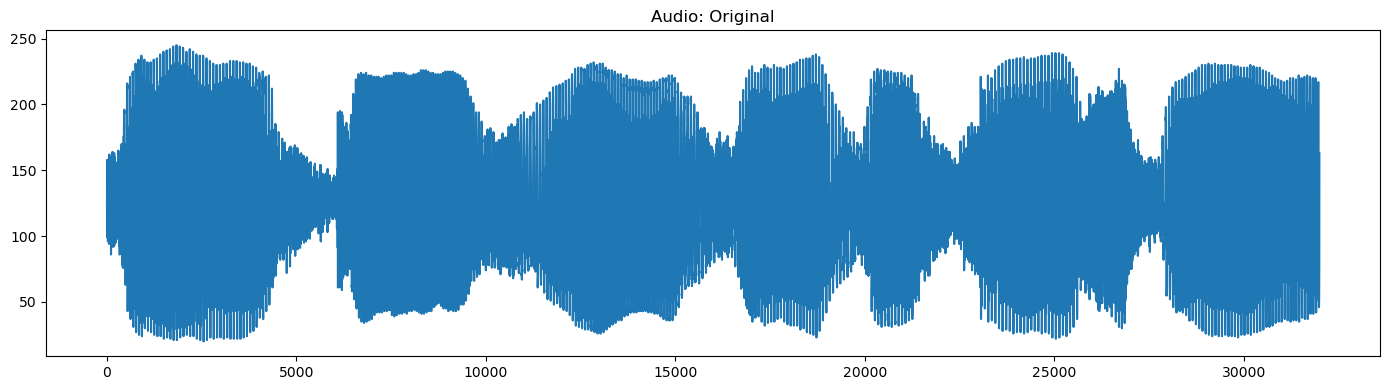

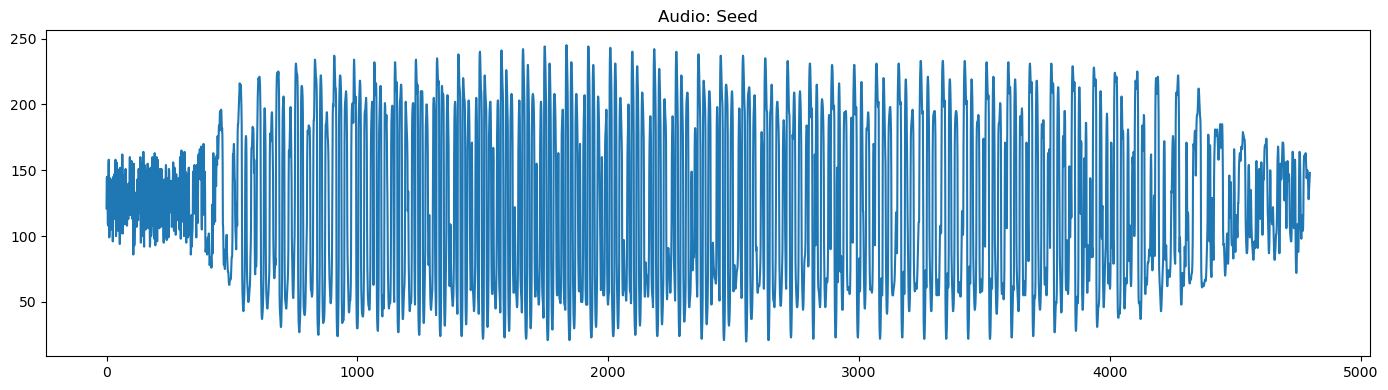

Generating:   0%|          | 103/24000 [00:04<17:19, 22.99it/s]


KeyboardInterrupt: 

In [ ]:

def gen(i):
    # Get one batch from test_loader; 
    audio, _ = next(iter(test_loader))     # x: [B, T-1] tokens (Long)
    audio = audio[i, :].unsqueeze(0).to(device)

    print(audio.shape)

    play_encoded_sample(audio.cpu())
    display_waveform(audio.cpu(), "Original")

    # Seconds to seed the generation with.
    seconds_to_seed = 0.3
    length_to_seed = int(16000*seconds_to_seed - 1)
    seed = audio[:1, : length_to_seed]         # [1, seed_len]; ensure <= available length

    # Seconds to generate.
    sec_to_generate = 1.7
    n_new = int(16000 * sec_to_generate)

    play_encoded_sample(seed.cpu())
    display_waveform(seed.cpu(), "Seed")

    audio_full = generate_continuation(
        model.compiled_model,
        seed_tokens=seed,
        n_steps=n_new,
        temperature=0.8,      # tweak 0.7–1.2
        top_k=50,            # optional; try None or 50–200
        device=device,
    )
    # audio_full_greedy = generate_greedy(model.base_model, seed, n_new, device=device)

    play_encoded_sample(audio_full.cpu())
    display_waveform(audio_full.cpu(), "audio_full")

    # play_encoded_sample(audio_full_greedy.cpu())
    # display_waveform(audio_full_greedy.cpu(), "audio_full_greedy")


gen(0)
gen(1)
gen(2)
gen(3)

In [ ]:
rf = model.get_receptive_field()

x_batch, y_batch = next(iter(train_loader))   # use the training loader for the overfit window
i = 0  # or pick the exact index you overfit on
# Optionally pick a prefix length N to avoid pads; else use full length
N = min(8000, x_batch.size(1))                # example: 0.5s @16k if tokens==samples
q = x_batch[i:i+1, :N].to(device)             # [1, N]
y = y_batch[i:i+1, :N].to(device)             # [1, N]

# q: [1, W] tokens of the SAME training window you overfit
S = max(rf, (q.size(1)-1)//2)            # seed ≥ RF, inside the same window
seq = q[:, :S].to(device)

with torch.no_grad():
    for _ in tqdm(range((q.size(1)-1) - S)):
        ctx = seq[:, -rf:] if seq.size(1) > rf else seq
        logits = model.base_model(ctx)[:, -1, :].float()  # cast logits to fp32
        nxt = logits.argmax(-1, keepdim=True)  # greedy
        seq = torch.cat([seq, nxt], 1)

pred = seq[:, S:]                # [1, W-1-S]
tgt  = q[:, S+1:].to(device)
fr_acc = (pred == tgt).float().mean().item()
print("FR acc within-window:", fr_acc)